# MS-AR in Python

### Importing packages

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

### Global parameters

In [30]:
np.random.seed(42)
n_obs = 500

### Generating dummy data

In [31]:
returns = []
current_state = 0

for i in range(n_obs):
    if current_state == 0:
        returns.append(np.random.normal(0, 0.5))
        if np.random.rand() < 0.05:
            current_state = 1

    else:
        returns.append(np.random.normal(0, 2.0))
        if np.random.rand() < 0.10:
            current_state = 0

df = pd.DataFrame({'returns': returns})
print(df)

      returns
0    0.248357
1   -0.069132
2   -0.117077
3   -0.117068
4    0.789606
..        ...
495 -0.285373
496 -0.276112
497  0.316466
498  0.773753
499  0.897939

[500 rows x 1 columns]


### Fitting the Markov switching model

In [32]:
model = sm.tsa.MarkovRegression(
    df['returns'],
    k_regimes=2,
    trend='c',
    switching_variance=True
)

result = model.fit()

print(result.summary())

                        Markov Switching Model Results                        
Dep. Variable:                returns   No. Observations:                  500
Model:               MarkovRegression   Log Likelihood                -607.560
Date:                Thu, 16 Apr 2026   AIC                           1227.119
Time:                        11:16:26   BIC                           1252.407
Sample:                             0   HQIC                          1237.042
                                - 500                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0201      0.027      0.746      0.456      -0.033       0.073
sigma2         0.2285      0.020     11.712      0.0

### Extracting the 'hidden' states

In [33]:
prob_regime_1 = result.smoothed_marginal_probabilities[1]
print(prob_regime_1)

0      0.026091
1      0.019729
2      0.037140
3      0.120480
4      0.474503
         ...   
495    0.068031
496    0.035517
497    0.035792
498    0.070478
499    0.112966
Name: 1, Length: 500, dtype: float64


### Visualising the results

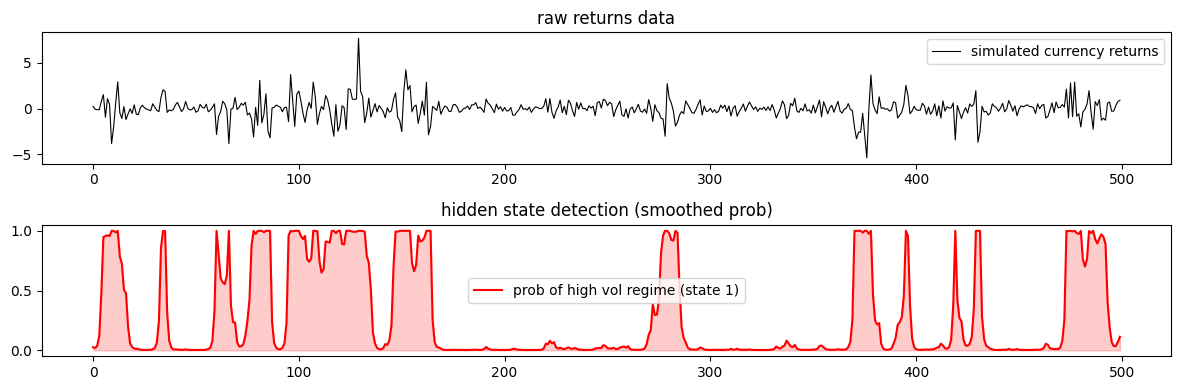

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4))

axes[0].plot(df['returns'], label='simulated currency returns', color='black', linewidth=0.8)
axes[0].set_title('raw returns data')
axes[0].legend()

axes[1].plot(prob_regime_1, label='prob of high vol regime (state 1)', color='red')
axes[1].set_title('hidden state detection (smoothed prob)')
axes[1].fill_between(df.index, 0, prob_regime_1, color='red', alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()